<!-- Zell 0 -->
# Hyperion Economy — lernende Agenten in Juno

Diese Demo trainiert drei lokale Q-Learning-Händler. Jeder Agent sieht dieselbe Hyperion-Wirtschaft, entscheidet sich für **halten**, **kaufen** oder **verkaufen** und speichert seine Erfahrung als kleine JSON-Datei. Es werden keine Online-Dienste und kein großes RL-Framework benötigt.

In [9]:
 # Zell 1
from pathlib import Path
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import learning_agents
importlib.reload(learning_agents)
from learning_agents import train_agents, evaluate_agents, load_agent_memory

print("Geladene Datei:", Path(learning_agents.__file__).resolve())

MEMORY_FILE = Path('agent_memory.json')
EPISODES = 30
YEARS = 20
SEED = 7

Geladene Datei: /private/var/mobile/Containers/Shared/AppGroup/8F8D7E23-4913-4B15-BD25-7A73752BEC14/File Provider Storage/Repositories/OpenAIWork2025/learning_agents.py


<!-- Zell 2 -->
## 1. Training starten

Für eine schnelle Präsentation reichen 10 Episoden. Für sichtbar stabileres Verhalten sind 30–50 Episoden sinnvoll.

In [10]:
 # Zell 3
result = train_agents(
    episodes=EPISODES, years=YEARS, seed=SEED, memory_path=str(MEMORY_FILE)
)
history = pd.DataFrame(result['history'])
print(f'{len(result["agents"])} Agenten trainiert.')
print(f'Gedächtnis: {MEMORY_FILE.resolve()}')
display(history.groupby('agent').tail(1)[['agent', 'final_value', 'trades', 'q_states', 'epsilon']])

3 Agenten trainiert.
Gedächtnis: /private/var/mobile/Containers/Shared/AppGroup/8F8D7E23-4913-4B15-BD25-7A73752BEC14/File Provider Storage/Repositories/OpenAIWork2025/agent_memory.json


,agent,final_value,trades,q_states,epsilon
87,Profit-Scout,987.11,6,23,0.05
88,Reserve-Keeper,1000.00,0,18,0.05
89,Hyperion-Speculator,1000.00,0,0,0.05


<!-- Zell 4 -->
## 2. Lernen sichtbar machen

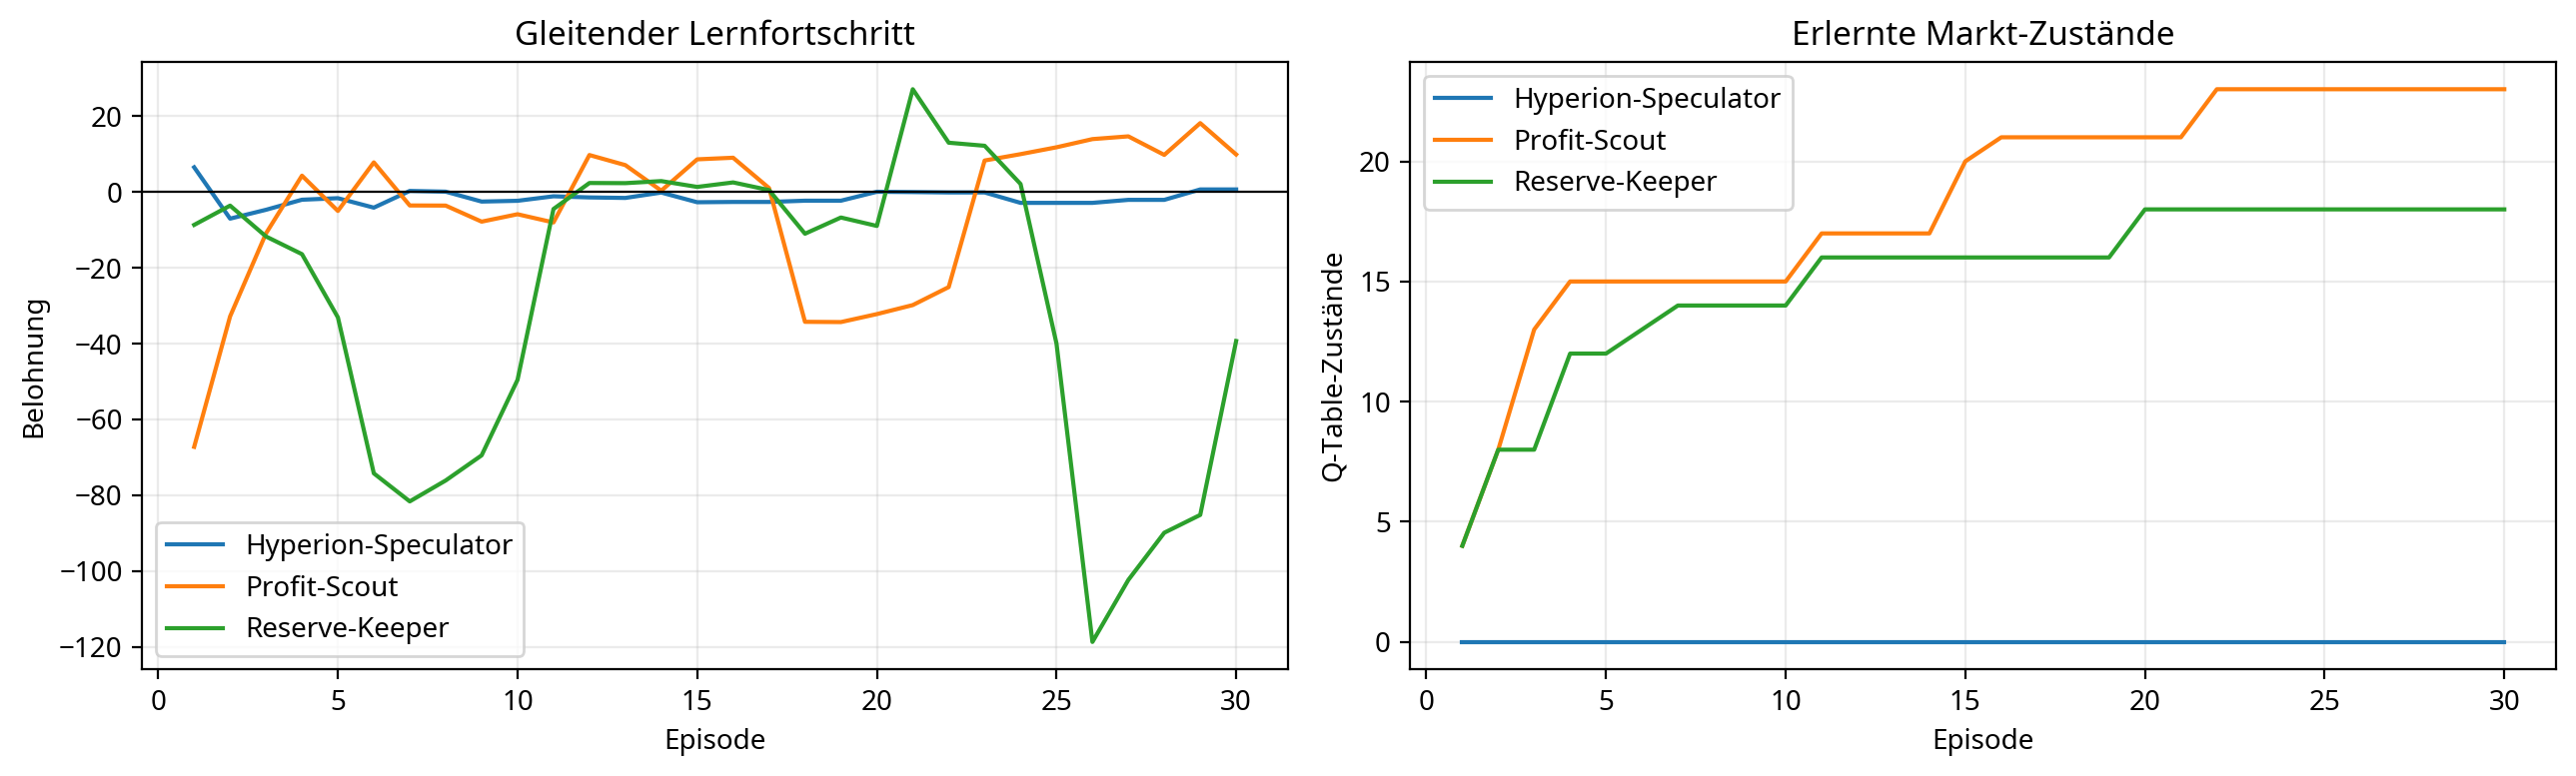

In [11]:
 # Zell 5
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for agent, frame in history.groupby('agent'):
    axes[0].plot(frame['episode'], frame['total_reward'].rolling(5, min_periods=1).mean(), label=agent)
    axes[1].plot(frame['episode'], frame['q_states'], label=agent)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Gleitender Lernfortschritt')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Belohnung')
axes[1].set_title('Erlernte Markt-Zustände')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Q-Table-Zustände')
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

<!-- Zell 6 -->
## 3. Unabhängige Bewertung

Die Bewertung nutzt neue Zufallsjahre und schaltet Exploration aus. Damit sehen wir, was die Agenten aus ihrem Gedächtnis abrufen, statt sie während der Messung weiterlernen zu lassen.

In [12]:
 # Zell 7
evaluation = pd.DataFrame(evaluate_agents(result['agents'], episodes=5, years=YEARS, seed=SEED + 1000))
print("Evaluationsspalten:", list(evaluation.columns))

summary = (evaluation.groupby('agent', as_index=False)
           .agg(avg_final_value=('final_value', 'mean'),
                avg_reward=('total_reward', 'mean'),
                avg_trades=('trades', 'mean')))

agent_algorithms = pd.DataFrame({
    'agent': [agent.name for agent in result['agents']],
    'algorithm': [getattr(agent, 'algorithm', 'unbekannt')
                  for agent in result['agents']],
})
algorithms = agent_algorithms.drop_duplicates('agent')
summary = summary.merge(algorithms, on='agent', how='left')
display(summary.sort_values('avg_final_value', ascending=False).round(2))

Evaluationsspalten: ['episode', 'agent', 'algorithm', 'final_value', 'total_reward', 'trades', 'epsilon', 'q_states']


,agent,avg_final_value,avg_reward,avg_trades,algorithm
0,Hyperion-Speculator,1000.00,0.00,0.0,bandit
2,Reserve-Keeper,999.67,-0.33,1.0,dyna-q
1,Profit-Scout,986.12,-13.88,10.6,sarsa


In [8]:
 # Zell 8
MODULE_SOURCE = r'''
import json
import random
from pathlib import Path

ACTIONS = ("halten", "kaufen", "verkaufen")


def _values(table, state):
    state = tuple(state)
    if state not in table:
        table[state] = {action: 0.0 for action in ACTIONS}
    return table[state]


def _best(values):
    maximum = max(values.values())
    return random.choice([
        action for action, value in values.items()
        if value == maximum
    ])


class Agent:
    def __init__(self, name, algorithm, alpha, gamma):
        self.name = name
        self.algorithm = algorithm
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = 0.30
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.94
        self.q_table = {}
        self.transitions = {}
        self.bandit_counts = {action: 0 for action in ACTIONS}
        self.bandit_values = {action: 0.0 for action in ACTIONS}

    def choose(self, state, explore=True):
        values = (
            self.bandit_values
            if self.algorithm == "bandit"
            else _values(self.q_table, state)
        )
        if explore and random.random() < self.epsilon:
            return random.choice(ACTIONS)
        return _best(values)

    def sarsa_update(self, state, action, reward, next_state, next_action):
        current = _values(self.q_table, state)
        following = _values(self.q_table, next_state)
        target = reward + self.gamma * following[next_action]
        current[action] += self.alpha * (target - current[action])

    def q_update(self, state, action, reward, next_state):
        current = _values(self.q_table, state)
        following = _values(self.q_table, next_state)
        target = reward + self.gamma * max(following.values())
        current[action] += self.alpha * (target - current[action])

    def bandit_update(self, action, reward):
        count = self.bandit_counts[action] + 1
        old = self.bandit_values[action]
        self.bandit_counts[action] = count
        self.bandit_values[action] = old + (reward - old) / count

    def remember(self, state, action, reward, next_state):
        self.transitions[(tuple(state), action)] = (
            float(reward), tuple(next_state)
        )

    def replay(self, steps=8):
        if not self.transitions:
            return
        items = list(self.transitions.items())
        for _ in range(min(steps, len(items))):
            (state, action), (reward, next_state) = random.choice(items)
            self.q_update(state, action, reward, next_state)


def _state(market, stock):
    price, stability, liquidity = market
    return (
        0 if price < 85 else 1 if price < 115 else 2,
        0 if stability < 0.38 else 1 if stability < 0.70 else 2,
        0 if liquidity < 0.35 else 1,
        0 if stock == 0 else 1,
    )


def _step(market, action, stock, cash):
    price, stability, liquidity = market
    old_value = cash + stock * price
    price = max(
        20.0,
        price
        * (1 + random.uniform(-0.08, 0.08))
        * (1 + random.uniform(-0.16, 0.16) * (1 - stability)),
    )
    stability = max(
        0.0, min(1.0, stability + random.uniform(-0.08, 0.08))
    )
    liquidity = max(
        0.0, min(1.0, liquidity + random.uniform(-0.10, 0.10))
    )
    if action == "kaufen" and cash >= price and liquidity > 0.18:
        cash -= price
        stock += 1
    elif action == "verkaufen" and stock > 0 and liquidity > 0.12:
        cash += price
        stock -= 1
    new_value = cash + stock * price
    return (price, stability, liquidity), stock, cash, new_value - old_value


def _make_agents(seed):
    random.seed(seed)
    return [
        Agent("Profit-Scout", "sarsa", 0.24, 0.94),
        Agent("Reserve-Keeper", "dyna-q", 0.16, 0.86),
        Agent("Hyperion-Speculator", "bandit", 0.20, 0.0),
    ]


def _episode(agent, years, explore, learn):
    market = (100.0, 0.72, 0.72)
    stock, cash = 0, 1000.0
    state = _state(market, stock)
    action = agent.choose(state, explore)
    total_reward = 0.0
    trades = 0

    for _ in range(years):
        old_stock = stock
        next_market, stock, cash, reward = _step(
            market, action, stock, cash
        )
        next_state = _state(next_market, stock)
        total_reward += reward
        trades += int(stock != old_stock)

        if learn and agent.algorithm == "sarsa":
            next_action = agent.choose(next_state, explore)
            agent.sarsa_update(
                state, action, reward, next_state, next_action
            )
        elif learn and agent.algorithm == "dyna-q":
            next_action = agent.choose(next_state, explore)
            agent.q_update(state, action, reward, next_state)
            agent.remember(state, action, reward, next_state)
            agent.replay()
        elif learn:
            next_action = agent.choose(next_state, explore)
            agent.bandit_update(action, reward)
        else:
            next_action = agent.choose(next_state, False)

        state, market, action = next_state, next_market, next_action

    if learn:
        agent.epsilon = max(
            agent.epsilon_min,
            agent.epsilon * agent.epsilon_decay,
        )
    return {
        "final_value": round(cash + stock * market[0], 2),
        "total_reward": round(total_reward, 2),
        "trades": trades,
    }


def train_agents(
    episodes=30, years=20, seed=7, memory_path="agent_memory.json"
):
    agents = _make_agents(seed)
    history = []
    for episode in range(episodes):
        for index, agent in enumerate(agents):
            random.seed(seed + episode * 101 + index)
            result = _episode(agent, years, True, True)
            history.append({
                "episode": episode + 1,
                "agent": agent.name,
                "algorithm": agent.algorithm,
                **result,
                "q_states": len(agent.q_table),
                "epsilon": round(agent.epsilon, 6),
            })
    _save(agents, memory_path)
    return {"agents": agents, "history": history}


def evaluate_agents(agents, episodes=5, years=20, seed=1007):
    rows = []
    for episode in range(episodes):
        for index, agent in enumerate(agents):
            random.seed(seed + episode * 101 + index)
            result = _episode(agent, years, False, False)
            rows.append({
                "episode": episode + 1,
                "agent": agent.name,
                "algorithm": agent.algorithm,
                **result,
                "epsilon": agent.epsilon,
                "q_states": len(agent.q_table),
            })
    return rows


def _save(agents, path):
    data = []
    for agent in agents:
        data.append({
            "name": agent.name,
            "algorithm": agent.algorithm,
            "alpha": agent.alpha,
            "gamma": agent.gamma,
            "epsilon": agent.epsilon,
            "q_table": [
                [list(state), values]
                for state, values in agent.q_table.items()
            ],
            "transitions": [
                [list(state), action, reward, list(next_state)]
                for (state, action), (reward, next_state)
                in agent.transitions.items()
            ],
            "bandit_counts": agent.bandit_counts,
            "bandit_values": agent.bandit_values,
        })
    Path(path).write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_agent_memory(path="agent_memory.json", seed=7):
    agents = _make_agents(seed)
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    lookup = {agent.name: agent for agent in agents}
    for item in data:
        agent = lookup[item["name"]]
        agent.algorithm = item.get("algorithm", agent.algorithm)
        agent.alpha = item.get("alpha", agent.alpha)
        agent.gamma = item.get("gamma", agent.gamma)
        agent.epsilon = item.get("epsilon", agent.epsilon)
        agent.q_table = {
            tuple(state): values
            for state, values in item.get("q_table", [])
        }
        agent.transitions = {
            (tuple(state), action): (reward, tuple(next_state))
            for state, action, reward, next_state
            in item.get("transitions", [])
        }
        agent.bandit_counts.update(item.get("bandit_counts", {}))
        agent.bandit_values.update(item.get("bandit_values", {}))
    return agents
'''

Path("learning_agents.py").write_text(MODULE_SOURCE, encoding="utf-8")
print("learning_agents.py aktualisiert.")

learning_agents.py aktualisiert.


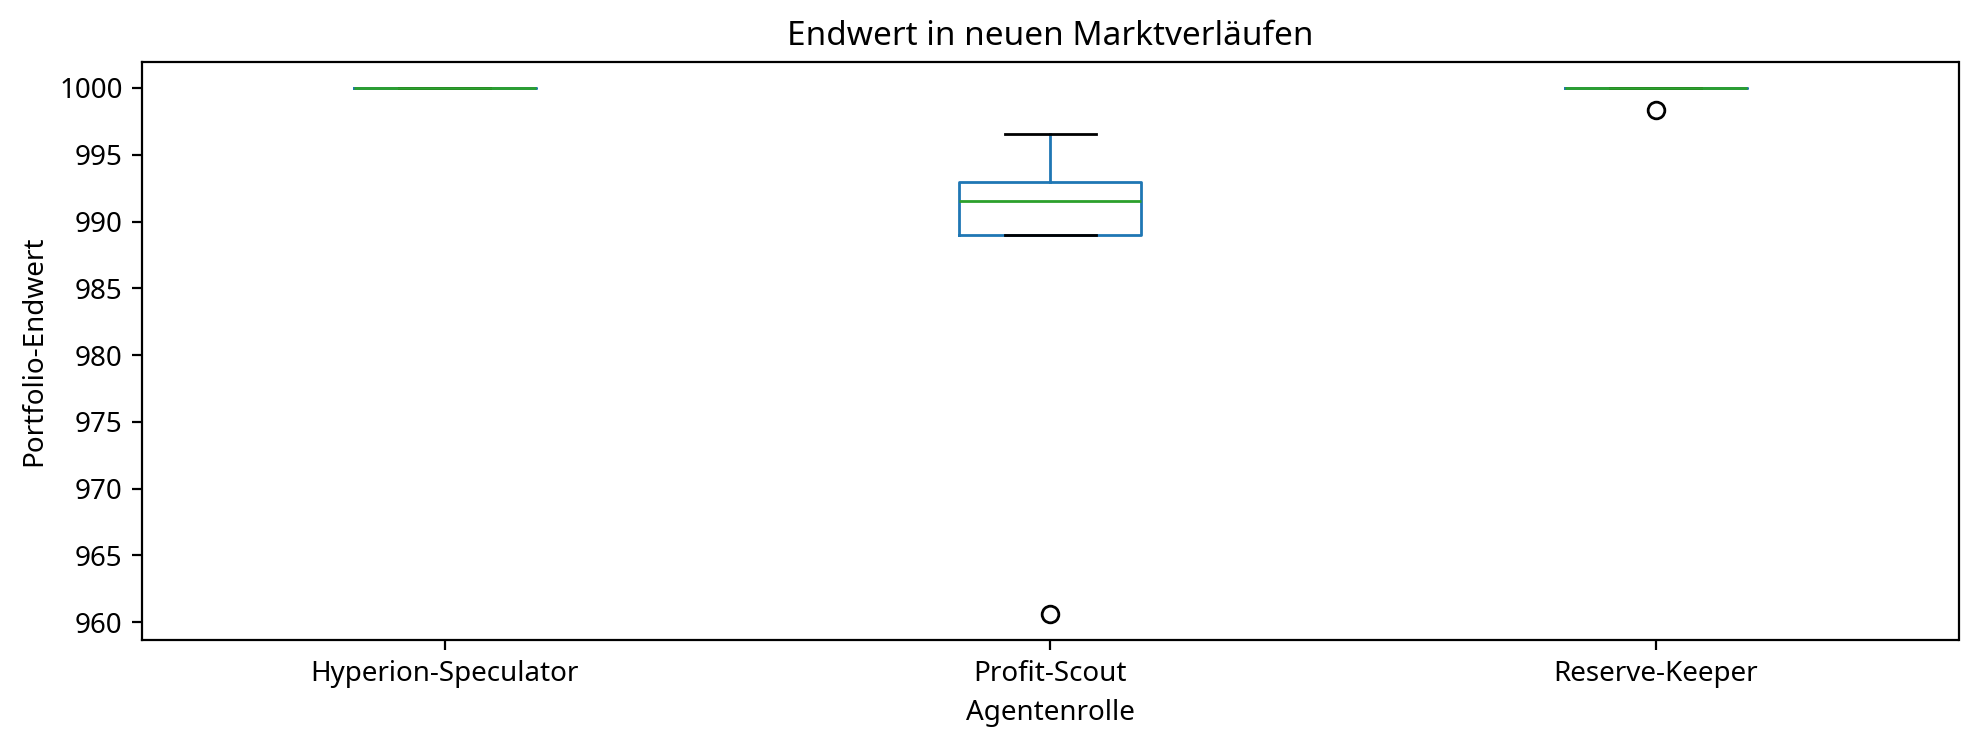

In [13]:
 # Zell 9
fig, axis = plt.subplots(figsize=(10, 4))
evaluation.boxplot(column='final_value', by='agent', ax=axis, grid=False)
axis.set_title('Endwert in neuen Marktverläufen')
axis.set_xlabel('Agentenrolle')
axis.set_ylabel('Portfolio-Endwert')
plt.suptitle('')
plt.tight_layout()
plt.show()

<!-- Zell 10 -->
## 4. Gedächtnis prüfen und später fortsetzen

In [14]:
 # Zell 11
restored = load_agent_memory(str(MEMORY_FILE), seed=SEED)
memory_view = pd.DataFrame({
"agent": [agent.name for agent in restored],
"algorithm": [agent.algorithm for agent in restored],
"q_states": [len(agent.q_table) for agent in restored],
"epsilon": [agent.epsilon for agent in restored],
"known_actions": [sum(len(row) for row in agent.q_table.values()) for agent in restored],
"bandit_counts": [agent.bandit_counts for agent in restored],
})
display(memory_view)
print('Die Datei kann beim nächsten Juno-Lauf wieder geladen werden.')

,agent,algorithm,q_states,epsilon,known_actions,bandit_counts
0,Profit-Scout,sarsa,23,0.05,69,"{'halten': 0, 'kaufen': 0, 'verkaufen': 0}"
1,Reserve-Keeper,dyna-q,18,0.05,54,"{'halten': 0, 'kaufen': 0, 'verkaufen': 0}"
2,Hyperion-Speculator,bandit,0,0.05,0,"{'halten': 35, 'kaufen': 34, 'verkaufen': 531}"


Die Datei kann beim nächsten Juno-Lauf wieder geladen werden.


<!-- Zell 12 -->
## 5. Optional: interaktiver Kurztest

Wenn `ipywidgets` in Juno verfügbar ist, kann die Trainingslänge direkt auf dem iPad verändert werden. Ohne Widgets bleibt das feste Training oben vollständig nutzbar.

In [15]:
 # Zell 13
try:
    import ipywidgets as widgets
    def quick_training(episodes=10, years=12):
        quick = train_agents(episodes=episodes, years=years, seed=SEED)
        frame = pd.DataFrame(quick['history'])
        display(frame.groupby('agent').tail(1)[['agent', 'final_value', 'trades', 'q_states']])
    display(widgets.interact(
        quick_training,
        episodes=widgets.IntSlider(value=10, min=5, max=60, step=5),
        years=widgets.IntSlider(value=12, min=5, max=30, step=1),
    ))
except ImportError:
    print('ipywidgets ist optional. Die festen Notebook-Zellen funktionieren trotzdem.')

interactive(children=(IntSlider(value=10, description='episodes', max=60, min=5, step=5), IntSlider(value=12, …

<function __main__.quick_training(episodes=10, years=12)>

<!-- Zell 14 -->
### Demo-Erzählung

- **Profit-Scout** sucht stärker nach Rendite und akzeptiert Schwankungen.
- **Reserve-Keeper** wird für Risiko und instabile Jahre stärker bestraft.
- **Hyperion-Speculator** handelt opportunistisch, ohne ganz so risikoaggressiv zu sein.

Die Agenten sind absichtlich transparent: Der Zustand besteht aus Preisband, Stabilität, Liquidität und Bestand; das Gedächtnis ist eine einfache Q-Tabelle. Das ist eine gute Demo-Basis für spätere Erweiterungen wie Nachrichten-Agenten, Multi-Agenten-Handel oder komplexere Belohnungen.